In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

import seaborn as sns
sns.set(font_scale=1.5)

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

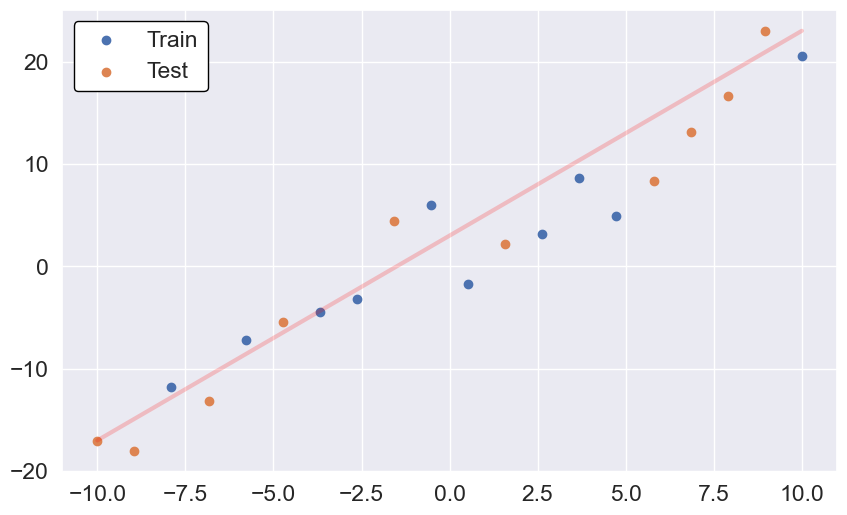

In [7]:
X = np.linspace(-10, 10, 20)

y = 2 * X + 3 + np.random.randn(20) * 3

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, random_state=42)
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, label="Train")
plt.scatter(X_test, y_test, label="Test")
plt.plot(X, 2 * X + 3, color='red', lw=3, alpha = 0.2)
legend_box = plt.legend(framealpha=1).get_frame()
legend_box.set_facecolor('white')
legend_box.set_edgecolor('black')
plt.show()

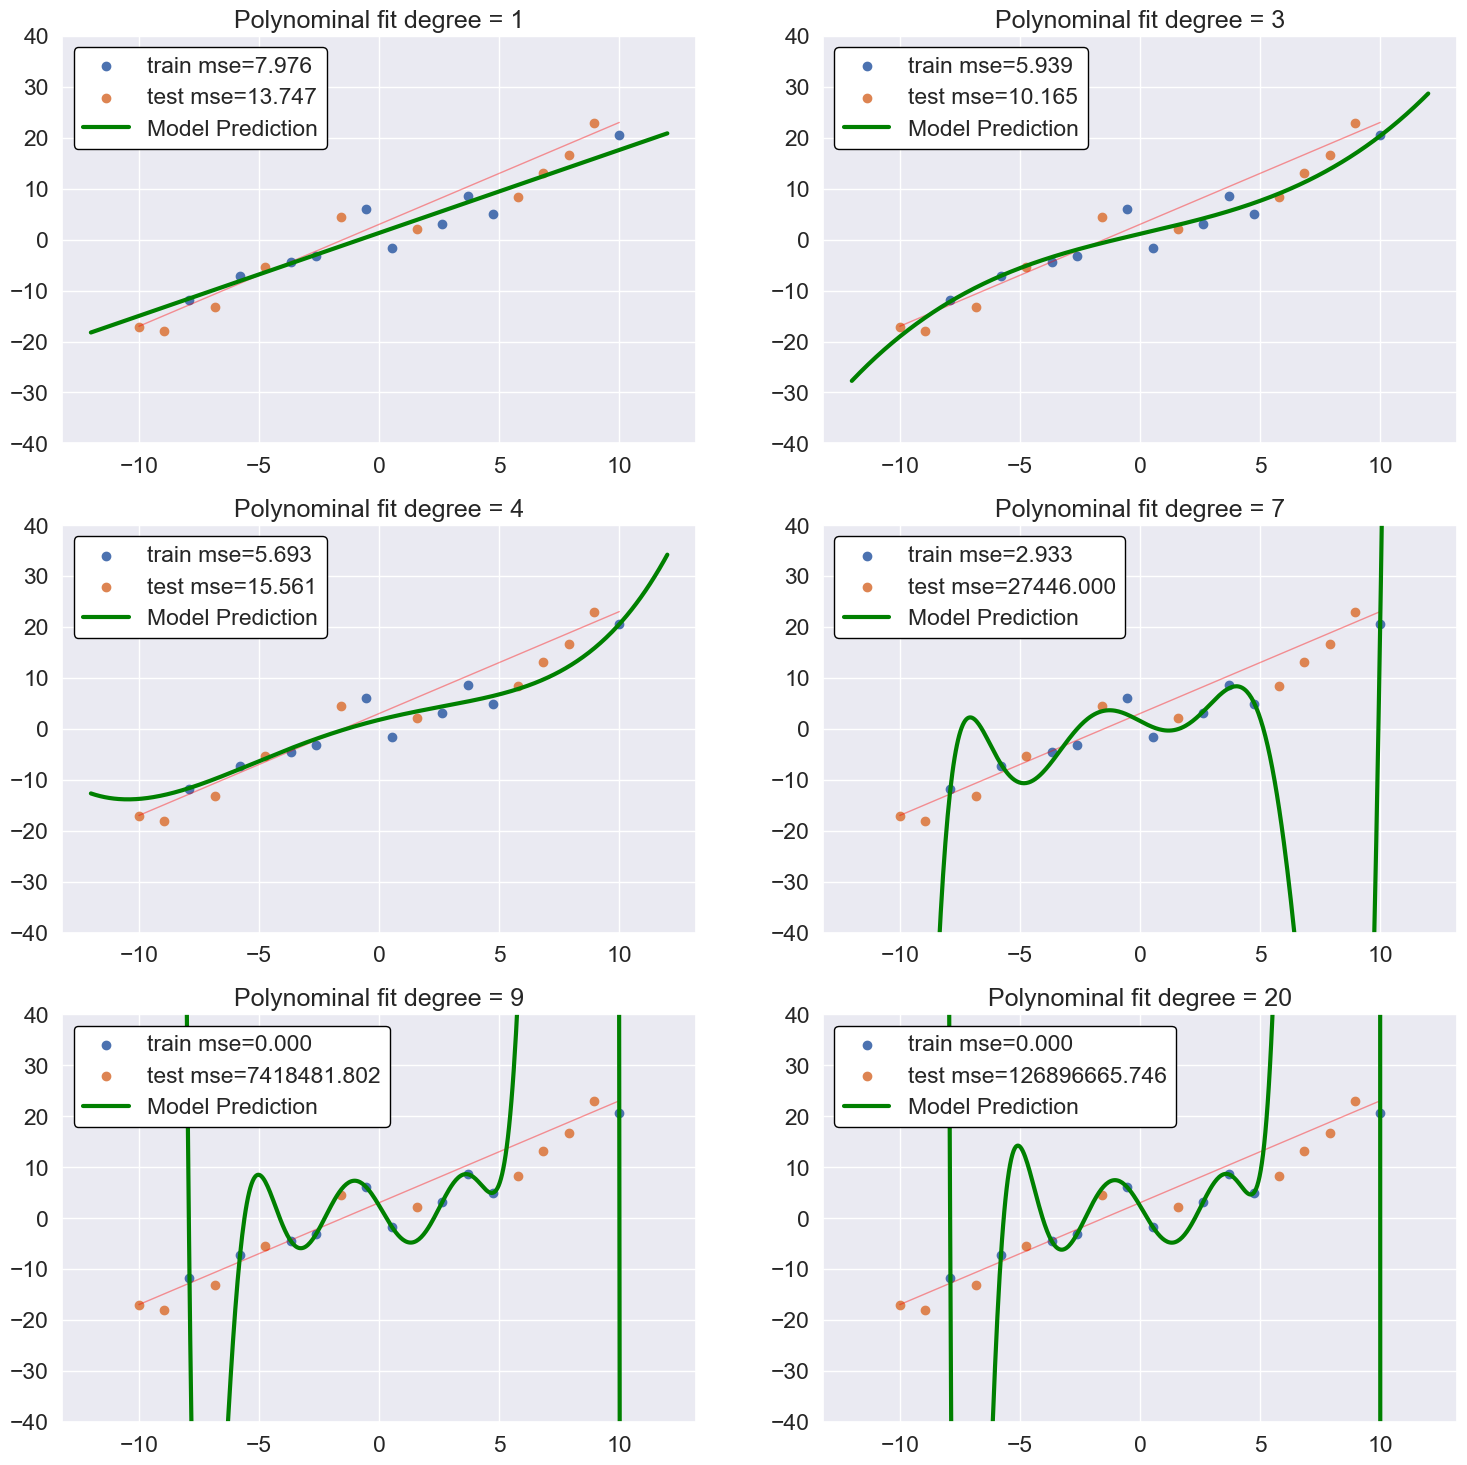

In [9]:
grid = np.linspace(-12, 12, 500)

fig, ax = plt.subplots(3, 2, figsize=(18, 18))

ax = ax.ravel()

for i, deg in enumerate([1, 3, 4, 7, 9, 20]):

    poly = np.polyfit(X_train, y_train, deg)
    ax[i].set_title('Polynominal fit degree = ' + str(deg))
    ax[i].scatter(X_train, y_train,
                label='train mse={:.3f}'.format(mean_squared_error(y_train, np.polyval(poly, X_train))))
    ax[i].scatter(X_test, y_test,
                label='test mse={:.3f}'.format(mean_squared_error(y_test, np.polyval(poly, X_test))))
    ax[i].set_ylim(-40, 40)
    ax[i].plot(X, 2 * X + 3, color='red', lw=1, alpha=0.4)
    ax[i].plot(grid, np.polyval(poly, grid), color='green', lw=3, label='Model Prediction')
    legend_box = ax[i].legend(framealpha=1).get_frame()
    legend_box.set_facecolor("white")
    legend_box.set_edgecolor("black")
fig.show()                            

In [10]:
import pandas as pd

In [ ]:
df = pd.read_csv('http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data', sep=',')

columns = ('age workclass fnlwgt education educ-num martial-status occupation ralationship '
           'race sex capital-gain capital-loss hours-per-week native-country salary')

numeric_indices = np.array([0, 2, 4, 10, 11, 12])
categorical_indices = np.array([1, 3, 5, 6, 7, 8, 9, 13])

df.columns = columns.split() #Этот метод разделит датасет по колонкам как в массиве columns

df = df.replace('?', np.nan)

df = df.dropna()
df['salary'] = df['salary'].apply((lambda x: x=='>50K')) #пишем тру если зп больше, если нет то фолс


In [14]:
df.head()

,age,workclass,fnlwgt,education,educ-num,martial-status,occupation,ralationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,False
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,False
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,False
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,False
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,False


In [15]:
numeric_data = df[df.columns[numeric_indices]]

categorial_data =df[df.columns[categorical_indices]]
categorial_data.head()

,workclass,education,martial-status,occupation,ralationship,race,sex,native-country
0,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States
1,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States
2,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States
3,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba
4,Private,Masters,Married-civ-spouse,Exec-managerial,Wife,White,Female,United-States


Label-encoding, применяется редко, по сути всем уникальным значениям для определнного признака кодируется одной цифрой.
Так надо будет делать для каждой фичи.
Это в целом не эффективно, потому что у нас тогда разные категории имеют разный вклад. Например, в лин.регрессии признаки имеющие одинаковый вес, но один закодирован большим числом, будет вносить больший вклад в предсказание.

In [16]:
df['education'].unique(), df['education'].nunique()

(<StringArray>
 [   ' Bachelors',      ' HS-grad',         ' 11th',      ' Masters',
           ' 9th', ' Some-college',   ' Assoc-acdm',    ' Assoc-voc',
       ' 7th-8th',    ' Doctorate',  ' Prof-school',      ' 5th-6th',
          ' 10th',      ' 1st-4th',    ' Preschool',         ' 12th']
 Length: 16, dtype: str,
 16)

### Мы применим One-hot-encoding

В среднем он работает лучше, чем лейбл энкодинг.

In [17]:
dummy_features = pd.get_dummies(categorial_data)

In [ ]:
X = pd.concat([numeric_data, dummy_features], axis=1)
X_origin = df.iloc[:, :-1] #Делаем срез до -1, потому что последняя колонка это таргет (Salary)
X.head()

,age,fnlwgt,educ-num,capital-gain,capital-loss,hours-per-week,workclass_ ?,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,50,83311,13,0,0,13,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,215646,9,0,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,53,234721,7,0,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,28,338409,13,0,0,40,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,37,284582,14,0,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [22]:
y = df['salary']

In [23]:
X.shape, X_origin.shape

((32560, 108), (32560, 14))

In [24]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X.values, 
                                                    y.values, 
                                                    train_size=0.8, 
                                                    random_state=42)

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

Напишем функцию, визуализирующую поискц оптимального гиперпараметра модели по сетке. Используя идею кросс-валидации.

In [27]:
def search_and_draw(X, y, model, param_name, grid, param_scale='ordinary', draw=True):
    parameters = {param_name: grid}

    CV_model = GridSearchCV(
        estimator=model,
        param_grid=parameters,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=10)
    CV_model.fit(X, y)
    means = CV_model.cv_results_['mean_test_score']
    error = CV_model.cv_results_['std_test_score']

    if draw:
        plt.figure(figsize=(15,8))
        plt.title('choose ' + param_name)


        if (param_scale == 'log'):
            plt.xscale('log')

        plt.plot(grid, means, label='mean values of score', color='red', lw=3 )

        plt.fill_between(grid, means - 2 * error, means + 2 * error,
                        color='green',
                        label='filled area between errors',
                        alpha=0.5
        )        
        legend_box = plt.legend(framealpha=1).get_frame()
        legend_box.set_facecolor('white')
        legend_box.set_edgecolor('black')
        plt.xlabel('parameter')
        plt.ylabel('roc_auc')
        plt.show()

    return means, error        